PROBLEM STATEMENT:
An airline ground-handling team is analysing baggage problems using flight route, transfer count, baggage volume, and mishandling records.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df=pd.read_csv("/content/Q07_baggage_handling.csv")

In [39]:
df.head()

,baggage_tag,route_type,transfer_count,baggage_volume,route_distance_km,mishandled
0,BG00001,International,1,389,1155,No
1,BG00002,International,0,207,4814,No
2,BG00003,NaN,1,104,3034,No
3,BG00004,Domestic,2,142,7321,No
4,BG00005,Domestic,2,110,4567,No


In [40]:
df.tail()

,baggage_tag,route_type,transfer_count,baggage_volume,route_distance_km,mishandled
118,BG00119,Domestic,0,446,7270,Yes
119,BG00120,Domestic,0,406,8083,No
120,BG00061,Domestic,1,429,8233,No
121,BG00089,Domestic,1,362,7752,No
122,BG00070,Domestic,2,252,3466,No


In [41]:
df.shape

(123, 6)

In [42]:
print(df.dtypes)

baggage_tag          object
route_type           object
transfer_count        int64
baggage_volume        int64
route_distance_km     int64
mishandled           object
dtype: object


In [43]:
df.isnull().sum()

,0
baggage_tag,0
route_type,1
transfer_count,0
baggage_volume,0
route_distance_km,0
mishandled,2


In [44]:
df['route_type']=df['route_type'].fillna("unknown")
print(df['route_type'])

0      International
1      International
2            unknown
3           Domestic
4           Domestic
           ...      
118         Domestic
119         Domestic
120         Domestic
121         Domestic
122         Domestic
Name: route_type, Length: 123, dtype: object


In [45]:
df['mishandled']=df['mishandled'].fillna("No")
print(df['mishandled'])

0       No
1       No
2       No
3       No
4       No
      ... 
118    Yes
119     No
120     No
121     No
122     No
Name: mishandled, Length: 123, dtype: object


In [46]:
df.duplicated().sum()

np.int64(3)

In [47]:
df = df.drop_duplicates()

In [48]:
df['failure'] = df['mishandled'].map({
    'Yes': 1,
    'No': 0
})

In [49]:
route_rate = df.groupby('route_type')['failure'].mean()
print("Mishandling rate by route:")
print(route_rate)


Mishandling rate by route:
route_type
Domestic         0.111111
International    0.107143
unknown          0.000000
Name: failure, dtype: float64


In [50]:
transfer_rate = df.groupby('transfer_count')['failure'].mean()
print("Mishandling rate by transfers:")
print(transfer_rate)

Mishandling rate by transfers:
transfer_count
0    0.076923
1    0.075000
2    0.090909
3    0.187500
Name: failure, dtype: float64


In [51]:
df['transfer_complexity'] = df['transfer_count'] * 10

In [52]:
df['distance_group'] = pd.cut( df['route_distance_km'], bins=[0, 500, 1500, 5000, 10000], labels=['Short', 'Medium', 'Long', 'Very Long']
)
print(df[['route_distance_km', 'distance_group']])

     route_distance_km distance_group
0                 1155         Medium
1                 4814           Long
2                 3034           Long
3                 7321      Very Long
4                 4567           Long
..                 ...            ...
115               6576      Very Long
116               6584      Very Long
117               5564      Very Long
118               7270      Very Long
119               8083      Very Long

[120 rows x 2 columns]


In [53]:
print(route_rate.sort_values(ascending=False))

route_type
Domestic         0.111111
International    0.107143
unknown          0.000000
Name: failure, dtype: float64


In [54]:
transfer_rate = df.groupby('transfer_count')['failure'].mean()

print(transfer_rate.sort_values(ascending=False))

transfer_count
3    0.187500
2    0.090909
0    0.076923
1    0.075000
Name: failure, dtype: float64


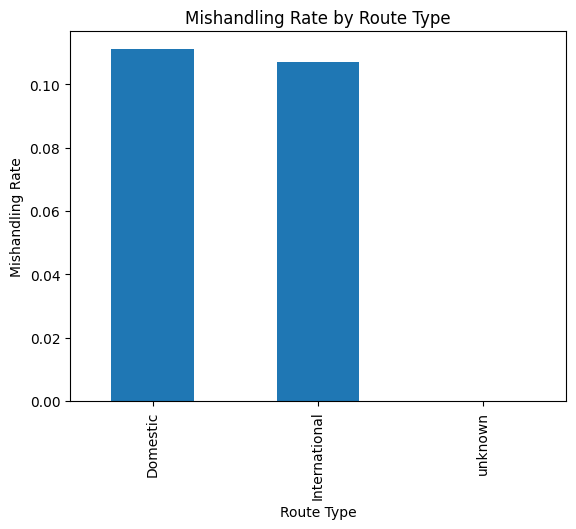

In [55]:
# Bar Chart - Mishandling by Route Type

route_rate.plot(kind='bar')

plt.title('Mishandling Rate by Route Type')
plt.xlabel('Route Type')
plt.ylabel('Mishandling Rate')

plt.show()

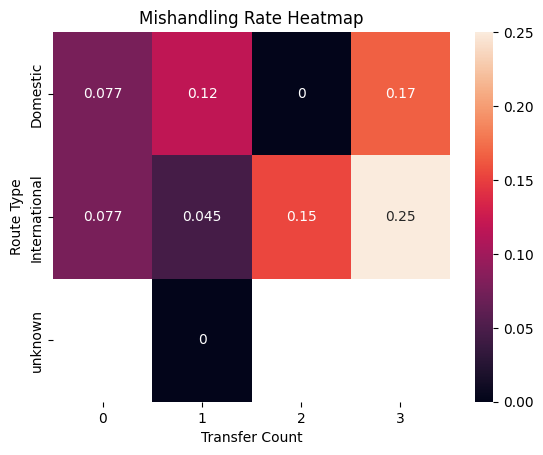

In [56]:
#Heatmap - Route Type vs Transfer Count
heatmap_data = df.pivot_table(
    index='route_type',
    columns='transfer_count',
    values='failure',
    aggfunc='mean'
)

sns.heatmap(
    heatmap_data,
    annot=True
)

plt.title('Mishandling Rate Heatmap')
plt.xlabel('Transfer Count')
plt.ylabel('Route Type')
plt.show()

In [59]:
df.to_csv("cleaned_baggage_dataset.csv", index=False)